In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

UPLOAD_DIR = Path("/mnt/user-data/uploads")
OUTPUT_DIR = Path("/mnt/user-data/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRICE_FILE = "merged_final_for_time_series.csv"
ARIST_FILE = "aristocrats_complete_for_time_series.csv"
IDX_FILE = "indices_for_time_series.csv"

STUDY_START = pd.Timestamp("2013-10-10")   # NOBL ETF inception date (user decision)
SENTINEL_YEAR_REMOVED = 2030               # "still active" marker
LOOKBACK_MONTHS_FOR_REMOVAL = 24           # window examined before each removal

# Manual overrides for symbols whose single Year_Added/Year_Removed pair
# cannot represent their real membership history. Each entry is a list of
# (start, end) tuples defining ALL active windows for that symbol, provided
# directly by the user rather than inferred from metadata.
#
# CB (Chubb): metadata shows Year_Added=2019, Year_Removed=2016, which is
# contradictory as a single window (removed before added). Per user
# instruction: CB was active from the study start, was removed effective
# 2016-01-01 (i.e. last active through 2015-12-31), and was re-added
# effective 2019-01-01, remaining active through the end of the dataset.
CUSTOM_MEMBERSHIP_OVERRIDES = {
    "CB": [
        (STUDY_START, pd.Timestamp("2015-12-31")),
        (pd.Timestamp("2019-01-01"), None),  # None = resolved to dataset_end at runtime
    ],
}


def build_membership_windows(prices: pd.DataFrame, arist: pd.DataFrame, idx: pd.DataFrame):
    """
    Builds usable membership window(s) per equity. Most equities get exactly
    one window; CB gets two (see CUSTOM_MEMBERSHIP_OVERRIDES).

    GENERAL CASE (single window):
        usable_start = max(STUDY_START, Jan-1 of Year_Added, symbol's first price date)
        usable_end   = min(dataset_end,
                            [Jan-1 of Year_Removed minus 1 day] if not sentinel else dataset_end,
                            symbol's last price date)

    CONVENTION (per user decision): both Year_Added and Year_Removed are
    anchored to January 1st. A symbol added in year Y is active starting
    Jan-1-Y. A symbol removed in year Y is NOT active during year Y at all --
    its last active day is Dec-31 of the prior year.

    CUSTOM OVERRIDE CASE (currently only CB): explicit user-provided window
    list is used instead of the formula above, since CB's single
    Year_Added/Year_Removed pair (2019/2016) cannot represent its actual
    two-stint membership history.
    """
    dataset_end = prices["Date"].max()

    price_span = prices.groupby("Symbol")["Date"].agg(["min", "max"]).reset_index()
    price_span.columns = ["Symbol", "Price_First_Date", "Price_Last_Date"]

    equities = arist.rename(columns={"Ticker": "Symbol"}).copy()
    equities = equities.merge(price_span, on="Symbol", how="left")

    anomalies = []
    rows = []
    for _, r in equities.iterrows():
        sym = r["Symbol"]
        company, sector = r["Company"], r["Sector"]

        # if pd.isna(r["Price_First_Date"]):
            # anomalies.append({"Symbol": sym, "Issue": "No price data found for this symbol at all"})
            # continue

        price_first, price_last = r["Price_First_Date"], r["Price_Last_Date"]

        if sym in CUSTOM_MEMBERSHIP_OVERRIDES:
            # --- CUSTOM OVERRIDE PATH ---
            anomalies.append({
                "Symbol": sym,
                "Issue": f"Year_Added ({int(r['Year_Added'])}) / Year_Removed ({int(r['Year_Removed'])}) "
                         f"metadata is not usable as a single window for this symbol. Resolved using an "
                         f"explicit user-provided multi-window override instead (see membership windows output).",
            })
            windows_spec = CUSTOM_MEMBERSHIP_OVERRIDES[sym]
            for i, (win_start, win_end) in enumerate(windows_spec, start=1):
                win_end = dataset_end if win_end is None else win_end
                usable_start = max(STUDY_START, win_start, price_first)
                usable_end = min(dataset_end, win_end, price_last)
                is_last_segment = (i == len(windows_spec))
                rows.append({
                    "Symbol": sym, "Company": company, "Sector": sector,
                    "Window_Number": i,
                    "Year_Added": win_start.year,
                    "Year_Removed": None if is_last_segment else win_end.year + 1,
                    "Still_Active": is_last_segment,
                    "Usable_Start_Date": usable_start,
                    "Usable_End_Date": usable_end,
                    "Usable_Trading_Span_Days": (usable_end - usable_start).days,
                    "Valid_Window": usable_start <= usable_end,
                    "Source": "manual_override",
                })
            continue

        # --- GENERAL FORMULA PATH ---
        year_added = r["Year_Added"]
        year_removed = r["Year_Removed"]

        # if year_removed != SENTINEL_YEAR_REMOVED and year_removed < year_added:
            # anomalies.append({
                # "Symbol": sym,
                # "Issue": f"Year_Removed ({int(year_removed)}) is before Year_Added ({int(year_added)}) "
                         # f"-- likely reflects two different corporate entities/listings under the same "
                         # f"ticker (e.g. merger/rename). Needs manual clarification / override before use.",
            # })
            # continue  # don't guess a window for an unresolved anomalous record

        added_start = pd.Timestamp(year=int(year_added), month=1, day=1)
        
        if year_removed == SENTINEL_YEAR_REMOVED:
            removed_end = dataset_end
        else:
            removed_end = pd.Timestamp(year=int(year_removed), month=1, day=1) - pd.Timedelta(days=1)

        usable_start = max(STUDY_START, added_start, price_first)
        usable_end = min(dataset_end, removed_end, price_last)

        still_active = year_removed == SENTINEL_YEAR_REMOVED

        rows.append({
            "Symbol": sym, "Company": company, "Sector": sector,
            "Window_Number": 1,
            "Year_Added": int(year_added),
            "Year_Removed": None if still_active else int(year_removed),
            "Still_Active": still_active,
            "Usable_Start_Date": usable_start,
            "Usable_End_Date": usable_end,
            "Usable_Trading_Span_Days": (usable_end - usable_start).days,
            "Valid_Window": usable_start <= usable_end,
            "Source": "formula",
        })

    windows = pd.DataFrame(rows)
    anomalies_df = pd.DataFrame(anomalies)

    invalid = windows[~windows["Valid_Window"]]
    for _, r in invalid.iterrows():
        anomalies_df = pd.concat([anomalies_df, pd.DataFrame([{
            "Symbol": r["Symbol"],
            "Issue": f"Computed usable_start ({r['Usable_Start_Date'].date()}) is after "
                     f"usable_end ({r['Usable_End_Date'].date()}) -- no usable data in study period "
                     f"(window #{r['Window_Number']}).",
        }])], ignore_index=True)

    return windows, anomalies_df


def flag_price_panel(prices: pd.DataFrame, windows: pd.DataFrame):
    """
    Adds an In_Membership_Window boolean flag to every row of the price panel:
    True if the row's Symbol+Date falls within ANY of that symbol's valid
    usable membership windows (a symbol like CB can have more than one).
    Benchmark tickers (not in `windows`) are flagged False since they are not
    Aristocrat equities and are excluded from ML sample membership logic
    (they are used separately for benchmark comparisons).
    """
    valid_windows = windows[windows["Valid_Window"]][["Symbol", "Usable_Start_Date", "Usable_End_Date"]]

    # Many-to-many merge on Symbol (fine at this scale -- only CB has >1 window)
    merged = prices.merge(valid_windows, on="Symbol", how="left")
    merged["in_range"] = (
        merged["Usable_Start_Date"].notna()
        & (merged["Date"] >= merged["Usable_Start_Date"])
        & (merged["Date"] <= merged["Usable_End_Date"])
    )
    flag = merged.groupby(["Symbol", "Date"], as_index=False)["in_range"].any()
    flag = flag.rename(columns={"in_range": "In_Membership_Window"})

    result = prices.merge(flag, on=["Symbol", "Date"], how="left")
    result["In_Membership_Window"] = result["In_Membership_Window"].fillna(False)
    return result

In [2]:
# Load data from 3 source .csv files
# prices, arist, idx = load_data()
prices = pd.read_csv("merged_final_for_time_series.csv", parse_dates=["Date"])
aristocrats = pd.read_csv("aristocrats_complete_for_time_series.csv")
indexes = pd.read_csv("indices_for_time_series.csv")

In [3]:
# Construct membership boolean for each stock using the 10/10/2013 to 6/30/2026 dividend capture horizon.
windows, anomalies = build_membership_windows(prices, aristocrats, indexes)

valid = windows[windows["Valid_Window"]]
print(f"\n[Membership Windows] {len(windows)} equities processed, {len(valid)} with a valid usable window")
if len(anomalies):
    print(f"\n[WARNING] {len(anomalies)} anomalies flagged for manual review:")
    print(anomalies.to_string(index=False))

print(f"\n[Membership Windows] Sample (first 20):")
print(valid[["Symbol", "Sector", "Year_Added", "Year_Removed", "Still_Active",
                 "Usable_Start_Date", "Usable_End_Date", "Usable_Trading_Span_Days"]].head(20).to_string(index=False))


[Membership Windows] 86 equities processed, 85 with a valid usable window

[WARNING] 2 anomalies flagged for manual review:
Symbol                                                                                                                                                                                                      Issue
    CB Year_Added (2019) / Year_Removed (2016) metadata is not usable as a single window for this symbol. Resolved using an explicit user-provided multi-window override instead (see membership windows output).
   PBI                                                                                         Computed usable_start (2013-10-10) is after usable_end (2012-12-31) -- no usable data in study period (window #1).

[Membership Windows] Sample (first 20):
Symbol                 Sector  Year_Added  Year_Removed  Still_Active Usable_Start_Date Usable_End_Date  Usable_Trading_Span_Days
  ABBV            Health Care        2013           NaN          True     

**The issue with PBI make sense since the stock was both added and removed in 2013.  Please note that I have chosen to use January 1st as the marker for date added and date removed for the stocks in the Aristocrats list for the study period.**

In [5]:
# Quick look at simple stats for Usable_Trading_Span_Days
print(valid['Usable_Trading_Span_Days'].min())
print(valid['Usable_Trading_Span_Days'].max())
print(valid['Usable_Trading_Span_Days'].mean())
print(valid['Usable_Trading_Span_Days'].median())

82
4646
3360.764705882353
4646.0


**The minimum of 82 days concerns me a bit as I know there were a handful of symbols whose inclusion in the Aristocrats list was short-lived.  Let's take a quick look at, say, the first fifteen records.**

In [7]:
valid.sort_values(by='Usable_Trading_Span_Days').head(15)

,Symbol,Company,Sector,Window_Number,Year_Added,Year_Removed,Still_Active,Usable_Start_Date,Usable_End_Date,Usable_Trading_Span_Days,Valid_Window,Source
13,BMS,"Bemis Company, Inc.",Materials,1,2013,2014.0,False,2013-10-10,2013-12-31,82,True,formula
61,OTIS,Otis Worldwide Corporation,Industrials,1,2020,2021.0,False,2020-03-19,2020-12-31,287,True,formula
16,CARR,Carrier Global Corporation,Industrials,1,2020,2021.0,False,2020-03-19,2020-12-31,287,True,formula
36,FDO,Family Dollar Stores,Consumer Discretionary,1,2013,2015.0,False,2013-10-10,2014-12-31,447,True,formula
72,SIAL,Sigma-Aldrich,Materials,1,2013,2015.0,False,2013-10-10,2014-12-31,447,True,formula
32,ES,Eversource Energy,Utilities,1,2025,NaN,True,2025-01-01,2026-06-30,545,True,formula
31,ERIE,Erie Indemnity,Financials,1,2025,NaN,True,2025-01-01,2026-06-30,545,True,formula
37,FDS,FactSet Research Systems,Financials,1,2025,NaN,True,2025-01-01,2026-06-30,545,True,formula
68,RGLD,"Royal Gold, Inc.",Materials,1,2025,NaN,True,2025-01-01,2026-06-30,545,True,formula
70,RTX,RTX Corporation,Industrials,1,2019,2021.0,False,2019-01-01,2020-12-31,730,True,formula


In [10]:
# Affix the In_Membership_Window boolean to the prices DataFrame
flagged = flag_price_panel(prices, windows)
in_window = flagged["In_Membership_Window"].sum()
print(f"\n[Price Panel Flags] {in_window:,} of {len(flagged):,} total rows,\n "
    f"({100*in_window/len(flagged):.1f}%) fall within a valid membership window")
flagged.head()


[Price Panel Flags] 196,621 of 316,363 total rows,
 (62.2%) fall within a valid membership window


,Date,Open,High,Low,Close,Volume,Symbol,Dividend,In_Membership_Window
0,2013-01-02,34.919998,35.400002,34.099998,35.119999,13767900,ABBV,0.0,False
1,2013-01-03,35.000000,35.000000,34.160000,34.830002,16739300,ABBV,0.0,False
2,2013-01-04,34.619999,34.889999,34.250000,34.389999,21372100,ABBV,0.0,False
3,2013-01-07,34.150002,35.450001,34.150002,34.459999,17897100,ABBV,0.0,False
4,2013-01-08,34.290001,34.639999,33.360001,33.709999,17863300,ABBV,0.0,False


Note:  Those rows outside the membership windows consist of benchmark (sector and index) ticker rows and out-of-membership-range equity rows.

In [152]:
# Let's do a study of the number of symbols for each sector during the 
# membership windows.  This calculation will be performed for each month-end.
def sector_composition_over_time(windows: pd.DataFrame):
    """
    For each month-end in the study period, need to count how many equities per
    sector are within their usable membership window (i.e. an "active
    Aristocrat" for modeling purposes at that point in time).
    """
    valid = windows[windows["Valid_Window"]]
    month_ends = pd.date_range(STUDY_START, valid["Usable_End_Date"].max(), freq="ME")

    records = []
    for month_end in month_ends:
        active = valid[(valid["Usable_Start_Date"] <= month_end) & (valid["Usable_End_Date"] >= month_end)]
        counts = active["Sector"].value_counts()
        rec = {"Month_End": month_end, "Total_Active": len(active)}
        rec.update(counts.to_dict())
        records.append(rec)

    out = pd.DataFrame(records).fillna(0)
    cols = ["Month_End", "Total_Active"] + sorted([c for c in out.columns if c not in ("Month_End", "Total_Active")])
    return out[cols]

In [17]:
# Let's look at sector composition over time using month-end markers
sector_comp = sector_composition_over_time(windows)
print(f"\n[Sector Composition] Computed for {len(sector_comp)} month-end snapshots")
# print(f"   Start ({sector_comp.iloc[0]['Month_End'].date()}): Total active sectors = {int(sector_comp.iloc[0]['Total_Active'])}")
# print(f"   End   ({sector_comp.iloc[-1]['Month_End'].date()}): Total active sectors = {int(sector_comp.iloc[-1]['Total_Active'])}")
sector_comp.head(15)


[Sector Composition] Computed for 153 month-end snapshots


,Month_End,Total_Active,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
0,2013-10-31,59,1.0,7,13,3,6,7,11,1,8,1,1
1,2013-11-30,59,1.0,7,13,3,6,7,11,1,8,1,1
2,2013-12-31,59,1.0,7,13,3,6,7,11,1,8,1,1
3,2014-01-31,58,1.0,7,13,3,6,7,11,1,7,1,1
4,2014-02-28,58,1.0,7,13,3,6,7,11,1,7,1,1
5,2014-03-31,58,1.0,7,13,3,6,7,11,1,7,1,1
6,2014-04-30,58,1.0,7,13,3,6,7,11,1,7,1,1
7,2014-05-31,58,1.0,7,13,3,6,7,11,1,7,1,1
8,2014-06-30,58,1.0,7,13,3,6,7,11,1,7,1,1
9,2014-07-31,58,1.0,7,13,3,6,7,11,1,7,1,1


It looks like the Consumer Staples and Industrials sectors have the largest representation for the period under study.

In [16]:
sector_comp.describe()

,Month_End,Total_Active,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
count,153,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.0,153.000000,153.000000,153.000000,153.000000,153.000000
mean,2020-02-29 13:10:35.294117632,61.496732,0.647059,5.392157,13.679739,2.490196,6.588235,7.0,12.934641,1.431373,7.254902,2.019608,2.058824
min,2013-10-31 00:00:00,55.000000,0.000000,4.000000,13.000000,2.000000,5.000000,7.0,11.000000,1.000000,6.000000,1.000000,1.000000
25%,2016-12-31 00:00:00,56.000000,0.000000,4.000000,13.000000,2.000000,6.000000,7.0,11.000000,1.000000,6.000000,1.000000,1.000000
50%,2020-02-29 00:00:00,64.000000,1.000000,6.000000,13.000000,2.000000,7.000000,7.0,13.000000,1.000000,8.000000,3.000000,2.000000
75%,2023-04-30 00:00:00,66.000000,1.000000,6.000000,15.000000,3.000000,7.000000,7.0,15.000000,2.000000,8.000000,3.000000,3.000000
max,2026-06-30 00:00:00,70.000000,1.000000,7.000000,16.000000,3.000000,9.000000,7.0,16.000000,2.000000,9.000000,3.000000,4.000000
std,NaN,5.353460,0.479454,0.994956,0.991102,0.501546,1.194997,0.0,1.834154,0.496894,1.103400,1.003091,1.131111


I see that zero is the minimum for the Communication Services sector.  I'm curious to see how many months in the period under study did not have any representation from this sector.

In [27]:
(sector_comp['Communication Services'] == 0).sum()

np.int64(54)

**That's four and a half years in the study period where there is no representation from the Communication Services sector.  I'll need to keep this mind for the upcoming machine learning.**

In [31]:
# Prep data for dividend-specific exploration by first identifying sector for each Aristocrat stock
sector_lookup = windows.drop_duplicates(subset="Symbol")[["Symbol", "Company", "Sector"]]
sector_lookup.head()

,Symbol,Company,Sector
0,ABBV,AbbVie,Health Care
1,ABT,Abbott Laboratories,Health Care
2,ADM,Archer-Daniels-Midland Co,Consumer Staples
3,ADP,Automatic Data Processing,Information Technology
4,AFL,AFLAC,Financials


In [32]:
# Now merge price data for records according to membership inclusion along with relevant sector
in_scope = flagged[flagged["In_Membership_Window"]].copy()
in_scope = in_scope.merge(sector_lookup, on="Symbol", how="left")
in_scope.head()

,Date,Open,High,Low,Close,Volume,Symbol,Dividend,In_Membership_Window,Company,Sector
0,2013-10-10,45.099998,45.680000,44.509998,45.680000,3967500,ABBV,0.4,True,AbbVie,Health Care
1,2013-10-11,45.700001,45.700001,44.959999,45.650002,2985700,ABBV,0.0,True,AbbVie,Health Care
2,2013-10-14,45.209999,46.450001,45.070000,46.330002,3377300,ABBV,0.0,True,AbbVie,Health Care
3,2013-10-15,46.049999,46.380001,45.750000,46.080002,3533300,ABBV,0.0,True,AbbVie,Health Care
4,2013-10-16,46.310001,47.270000,46.200001,47.060001,4399900,ABBV,0.0,True,AbbVie,Health Care


In [33]:
def yield_monthly(in_scope: pd.DataFrame) -> pd.DataFrame:
    """
    This function computes the trailing-twelve-month (TTM) dividend yield per symbol, sampled at each
    month-end: sum of dividends paid in the trailing 365 days / month-end closing price.
    """
    df = in_scope.sort_values(["Symbol", "Date"]).copy()

    records = []
    for sym, sub in df.groupby("Symbol"):
        sub = sub.set_index("Date")
        month_ends = pd.date_range(sub.index.min(), sub.index.max(), freq="ME")
        divs = sub[sub["Dividend"] > 0]["Dividend"]
        sector = sub["Sector"].iloc[0]
        company = sub["Company"].iloc[0]

        for month_end in month_ends:
            price_asof = sub.loc[:month_end]
            if price_asof.empty:
                continue
            close_price = price_asof["Close"].iloc[-1]

            ttm_start = month_end - pd.DateOffset(days=365)
            ttm_dividend = divs[(divs.index > ttm_start) & (divs.index <= month_end)].sum()
            ttm_yield = 100 * ttm_dividend / close_price if close_price else np.nan

            records.append({
                "Symbol": sym, "Company": company, "Sector": sector,
                "Month_End": month_end, "Close": close_price,
                "TTM_Dividend": ttm_dividend, "TTM_Yield_Pct": ttm_yield,
            })

    return pd.DataFrame(records)

def yield_summary(yields: pd.DataFrame) -> pd.DataFrame:
    """
    This function returns the distribution of TTM yield by sector and by year
    for mean, median, min, and max.
    """
    df = yields.copy()
    df["Year"] = df["Month_End"].dt.year

    by_sector_year = df.groupby(["Sector", "Year"]).agg(
        Mean_Yield_Pct=("TTM_Yield_Pct", "mean"),
        Median_Yield_Pct=("TTM_Yield_Pct", "median"),
        Min_Yield_Pct=("TTM_Yield_Pct", "min"),
        Max_Yield_Pct=("TTM_Yield_Pct", "max"),
        N_Symbol_Months=("TTM_Yield_Pct", "count"),
    ).reset_index()

    return by_sector_year.round(3)

In [34]:
# Let's start to explore the yield distribution using the in_scope price data
yields = yield_monthly(in_scope)
y_summary = yield_summary(yields)

In [35]:
yields.head()

,Symbol,Company,Sector,Month_End,Close,TTM_Dividend,TTM_Yield_Pct
0,ABBV,AbbVie,Health Care,2013-10-31,48.450001,0.4,0.825593
1,ABBV,AbbVie,Health Care,2013-11-30,48.450001,0.4,0.825593
2,ABBV,AbbVie,Health Care,2013-12-31,52.810001,0.4,0.757432
3,ABBV,AbbVie,Health Care,2014-01-31,49.230000,0.8,1.625025
4,ABBV,AbbVie,Health Care,2014-02-28,50.910000,0.8,1.571401


In [122]:
print(f"\n[Yield Distribution] Mean TTM yield: " 
      f"{yields['TTM_Yield_Pct'].mean():.2f}%")
print(f"[Yield Distribution] Median TTM yield: "
      f"{yields['TTM_Yield_Pct'].median():.2f}%")
print(f"[Yield Distribution] Standard deviation for TTM yield: "
      f"{yields['TTM_Yield_Pct'].std():.2f}%")


[Yield Distribution] Mean TTM yield: 2.36%
[Yield Distribution] Median TTM yield: 2.21%
[Yield Distribution] Standard deviation for TTM yield: 1.34%


The mean and median TTM yields are well below four percent.  I was hoping to have yields at this level as a dividend-capture strategy within a universe of 4+ percent yields has a better chance of succeeding.  The one saving grace is that one standard deviation brings the TTM yield up to 3.70% and two standard deviations brings it up to 5.04%.  This makes me feel a bit better.  Let's see what the remainder of the EDA shows.

In [118]:
y_summary.head(15)

,Sector,Year,Mean_Yield_Pct,Median_Yield_Pct,Min_Yield_Pct,Max_Yield_Pct,N_Symbol_Months
0,Communication Services,2013,0.000,0.000,0.000,0.000,3
1,Communication Services,2014,4.370,4.289,1.737,7.253,12
2,Communication Services,2015,7.287,7.313,6.933,7.599,12
3,Communication Services,2016,6.379,6.407,5.822,6.939,12
4,Communication Services,2017,6.659,6.643,6.061,7.712,12
5,Communication Services,2018,8.040,8.138,6.965,9.278,12
6,Communication Services,2019,7.919,7.937,6.911,8.853,12
7,Communication Services,2020,9.039,9.230,7.215,10.192,12
8,Communication Services,2021,10.042,9.846,8.768,12.063,12
9,Consumer Discretionary,2013,0.314,0.362,0.000,0.970,21


In [121]:
print(y_summary.groupby('Sector')['Mean_Yield_Pct'].mean())
print(y_summary.groupby('Sector')['Min_Yield_Pct'].mean())

Sector
Communication Services    6.637222
Consumer Discretionary    2.378857
Consumer Staples          2.414500
Energy                    3.903500
Financials                2.119857
Health Care               2.097857
Industrials               1.689000
Information Technology    2.261143
Materials                 1.665857
Real Estate               3.181714
Utilities                 2.935786
Name: Mean_Yield_Pct, dtype: float64
Sector
Communication Services    5.601333
Consumer Discretionary    1.306214
Consumer Staples          0.747786
Energy                    2.947214
Financials                0.301857
Health Care               0.568643
Industrials               0.341714
Information Technology    1.540571
Materials                 0.547929
Real Estate               2.265500
Utilities                 1.828500
Name: Min_Yield_Pct, dtype: float64


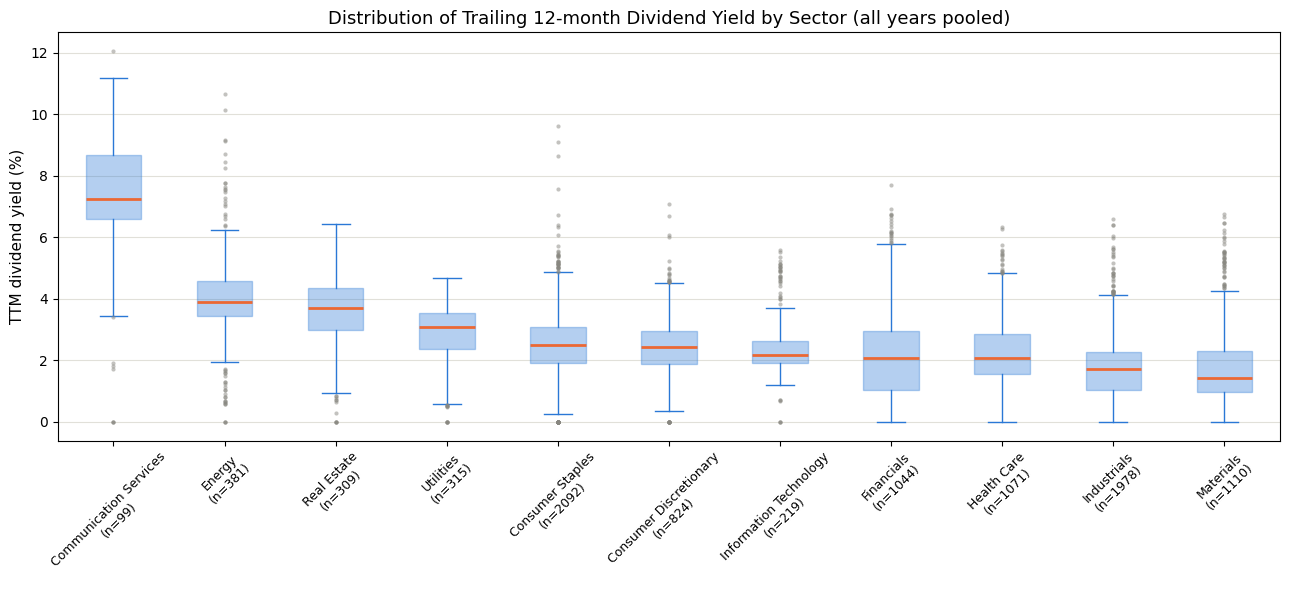


Sector order (by median yield, descending):
  Communication Services: median=7.23%, n=99
  Energy: median=3.91%, n=381
  Real Estate: median=3.72%, n=309
  Utilities: median=3.08%, n=315
  Consumer Staples: median=2.51%, n=2092
  Consumer Discretionary: median=2.43%, n=824
  Information Technology: median=2.19%, n=219
  Financials: median=2.09%, n=1044
  Health Care: median=2.06%, n=1071
  Industrials: median=1.71%, n=1978
  Materials: median=1.42%, n=1110


In [42]:
# Construct series of boxplots for TTM yield according to the 11 sectors.
# The sectors will be ordered by median yield (descending) so that the plot 
# reads left-to-right, from highest- to lowest-yielding sector.

import matplotlib.pyplot as plt

sector_order = (
    yields.groupby("Sector")["TTM_Yield_Pct"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

data_by_sector = [yields.loc[yields["Sector"] == s, "TTM_Yield_Pct"].dropna() for s in sector_order]
n_by_sector = [len(d) for d in data_by_sector]

fig, ax = plt.subplots(figsize=(13, 6))

bp = ax.boxplot(
    data_by_sector,
    tick_labels=[f"{s}\n(n={n})" for s, n in zip(sector_order, n_by_sector)],
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker="o", markersize=3, markerfacecolor="#888780",
                    markeredgecolor="none", alpha=0.5),
    medianprops=dict(color="#eb6834", linewidth=2),
    boxprops=dict(facecolor="#2a78d6", alpha=0.35, edgecolor="#2a78d6"),
    whiskerprops=dict(color="#2a78d6"),
    capprops=dict(color="#2a78d6"),
)

ax.set_ylabel("TTM dividend yield (%)", fontsize=11)
ax.set_title("Distribution of Trailing 12-month Dividend Yield by Sector (all years pooled)", fontsize=13)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)

fig.tight_layout()
# fig.savefig(OUTPUT_DIR / "section3_yield_boxplot_by_sector.png", dpi=150)
# plt.close(fig)
plt.show()

print("\nSector order (by median yield, descending):")
for s, n in zip(sector_order, n_by_sector):
    med = yields.loc[yields["Sector"] == s, "TTM_Yield_Pct"].median()
    print(f"  {s}: median={med:.2f}%, n={n}")


According to the above plots, the Communication Services sector afforded the highest TTM yields.  It's a shame that the membership stint for this sector was truncated and consisted of only one company (AT&T).  This also means that a lot of the overall return for each trade will have to be price recovery to the pre-ex-dividend price.  Unfortunately, for seven sectors the median TTM yield fell below the 3% mark.  This will make the objective of edging out a simple buy-and-hold strategy more difficult.

In [46]:
sector_lookup[sector_lookup['Sector'] == 'Communication Services']

,Symbol,Company,Sector
78,T,AT&T Inc.,Communication Services


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_yield_range(ax, sector_df: pd.DataFrame, sector_name: str):
    """
    This function will draw a max-min range chart on the given matplotlib Axes for one sector:
      - a vertical bar from Min_Yield_Pct to Max_Yield_Pct for each year
      - a marker at Median_Yield_Pct
    """
    years = sector_df["Year"]
    mins = sector_df["Min_Yield_Pct"]
    maxs = sector_df["Max_Yield_Pct"]
    medians = sector_df["Median_Yield_Pct"]
    heights = maxs - mins

    ax.bar(years, heights, bottom=mins, width=0.6,
           color="#2a78d6", alpha=0.35, label="Min-max range")
    ax.scatter(years, medians, color="#eb6834", zorder=3, s=30, label="Median")

    ax.set_title(sector_name, fontsize=11)
    ax.set_ylabel("TTM dividend yield (%)", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)

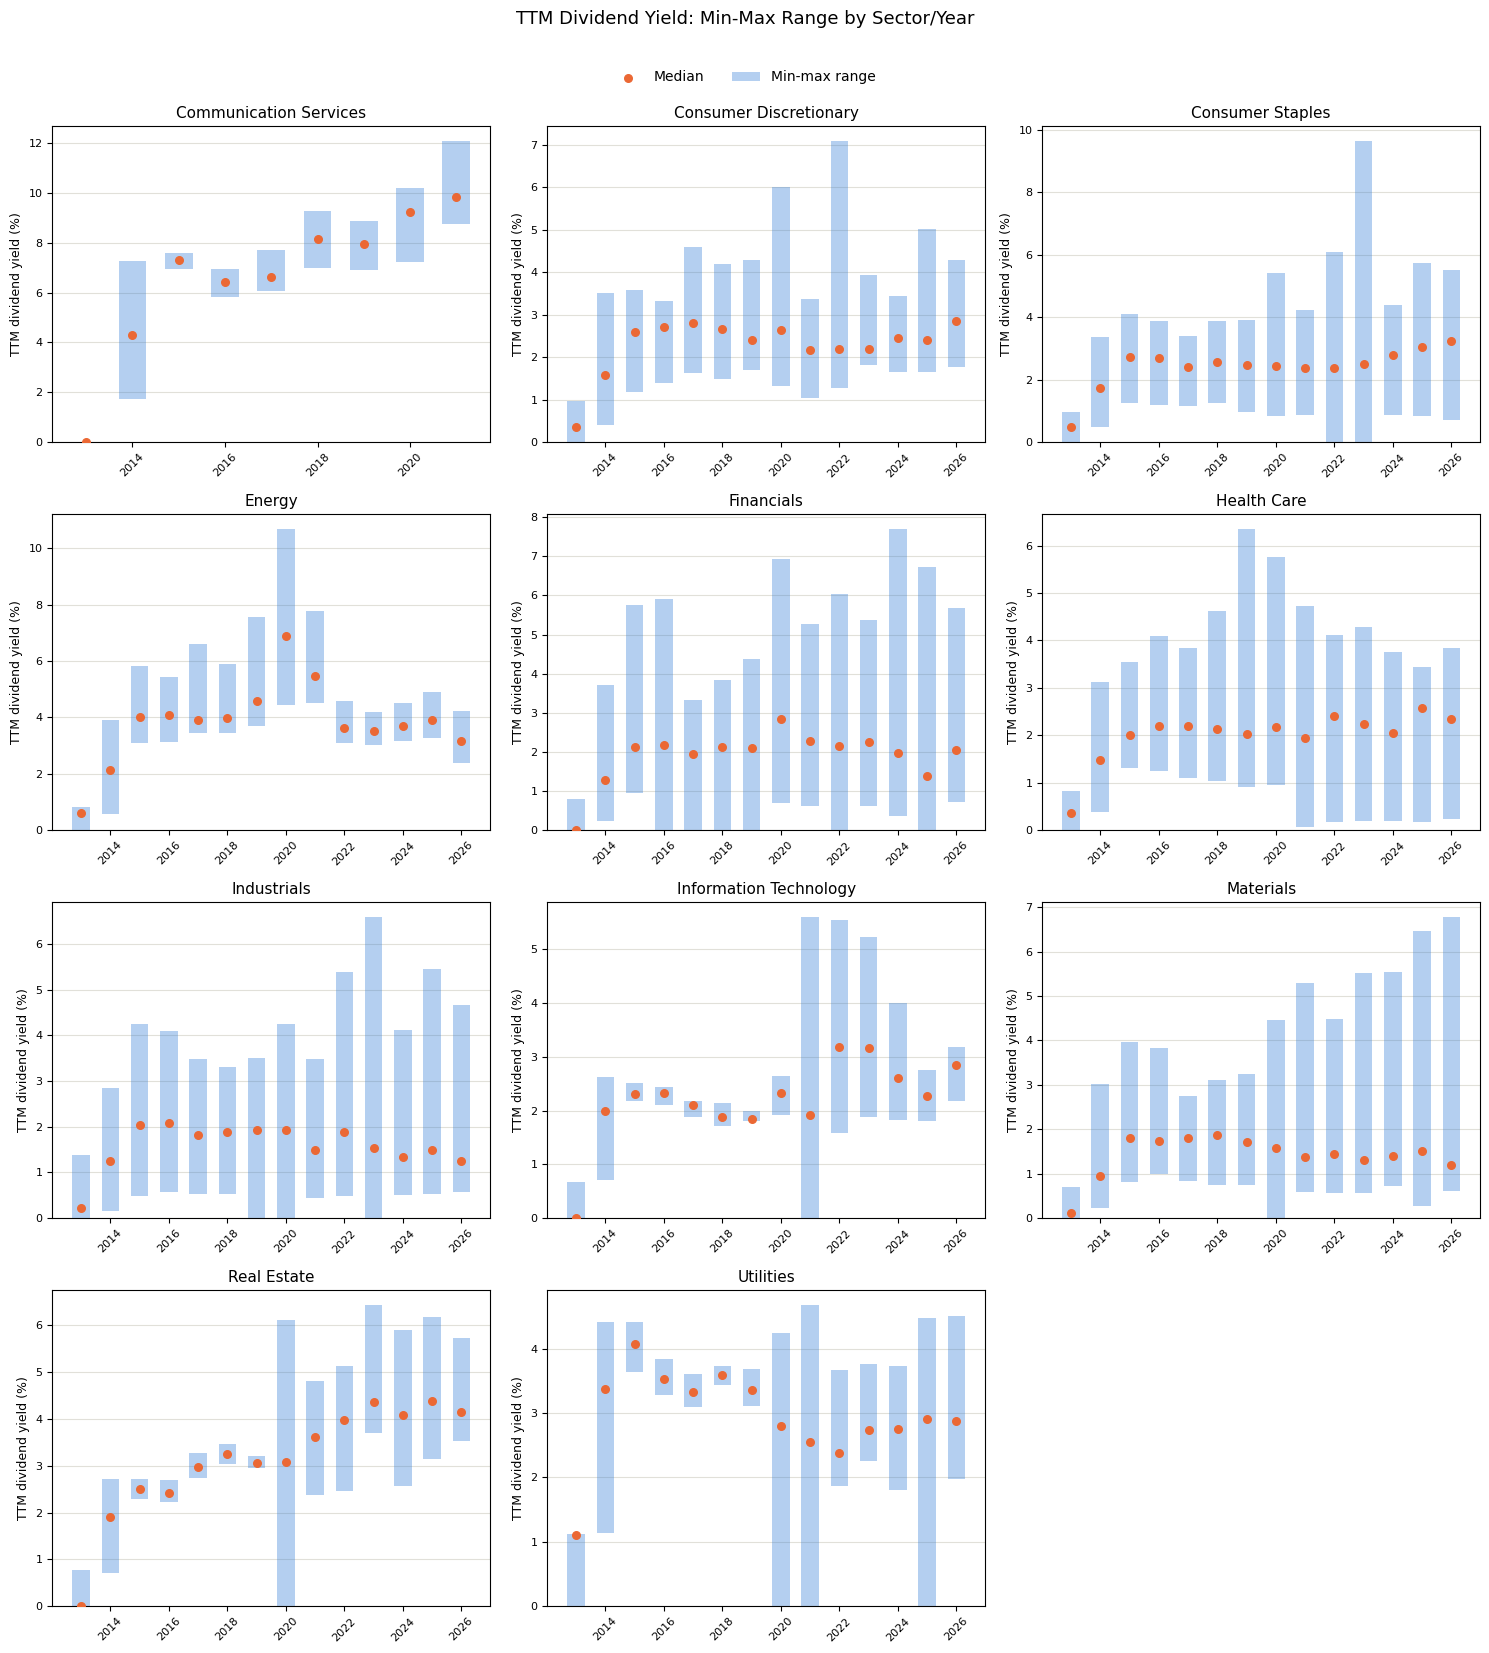

In [44]:
# --- All sectors, small multiples ---
sectors = sorted(y_summary["Sector"].unique())
n_cols = 3
n_rows = -(-len(sectors) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, sector in enumerate(sectors):
    sector_df = y_summary[y_summary["Sector"] == sector].sort_values("Year")
    plot_yield_range(axes[i], sector_df, sector)

for j in range(len(sectors), len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle("TTM Dividend Yield: Min-Max Range by Sector/Year", fontsize=13, y=1.03)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2, fontsize=10, frameon=False)
fig.tight_layout()
# fig.savefig(OUTPUT_DIR / "section3_yield_range_chart_all_sectors.png", dpi=150, bbox_inches="tight")
# plt.close(fig)
plt.show()

The median yields for Real Estate stocks in the Aristocrats list have been rising historically, and Communication Services yields were rising during their time in the study.  Historically, if an investor wanted steady average annual yields above 2%, should have focused on Discretionary, Staples, Energy, and Health Care.  Yields for Discretionary, Staples, Health Care, and Materials have remained relatively steady, albeit low.

In [47]:
# Explore ex-dividend price-drop ratio

def ex_dividend_price_drop(in_scope: pd.DataFrame) -> pd.DataFrame:
    """
    For each ex-dividend event, this function computes the price drop measured two ways:
      - Open-based:  Prev_Close - Open   (isolates the ex-div adjustment before
                       same-day trading noise; the more standard measure)
      - Close-based: Prev_Close - Close  (full-day return; noisier)
      
    Drop_Ratio = Drop / Dividend. 
    
    A ratio of 1.0 means price fell by exactly
    the dividend amount; <1 means a partial drop; >1 means an overdrop.
    """
    df = in_scope.sort_values(["Symbol", "Date"]).copy()
    df["Prev_Close"] = df.groupby("Symbol")["Close"].shift(1)

    events = df[df["Dividend"] > 0].copy()
    events = events.dropna(subset=["Prev_Close"])

    events["Drop_Open"] = events["Prev_Close"] - events["Open"]
    events["Drop_Close"] = events["Prev_Close"] - events["Close"]
    events["Drop_Ratio_Open"] = events["Drop_Open"] / events["Dividend"]
    events["Drop_Ratio_Close"] = events["Drop_Close"] / events["Dividend"]

    cols = ["Symbol", "Company", "Sector", "Date", "Dividend", "Prev_Close", "Open", "Close",
            "Drop_Open", "Drop_Close", "Drop_Ratio_Open", "Drop_Ratio_Close"]
    return events[cols].rename(columns={"Date": "Ex_Date"})


def drop_summary_by_sector(events: pd.DataFrame) -> pd.DataFrame:
    """Aggregates the ex-dividend drop ratio by sector (and overall)."""
    def agg_block(g):
        return pd.Series({
            "N_Events": len(g),
            "Mean_Drop_Ratio_Open": g["Drop_Ratio_Open"].mean(),
            "Median_Drop_Ratio_Open": g["Drop_Ratio_Open"].median(),
            "Std_Drop_Ratio_Open": g["Drop_Ratio_Open"].std(),
            "Mean_Drop_Ratio_Close": g["Drop_Ratio_Close"].mean(),
            "Median_Drop_Ratio_Close": g["Drop_Ratio_Close"].median(),
            "Std_Drop_Ratio_Close": g["Drop_Ratio_Close"].std(),
        })

    by_sector = events.groupby("Sector").apply(agg_block, include_groups=False).reset_index()
    overall = agg_block(events)
    overall["Sector"] = "ALL SECTORS (overall)"
    overall_df = pd.DataFrame([overall])[["Sector", "N_Events", "Mean_Drop_Ratio_Open", "Median_Drop_Ratio_Open",
                                           "Std_Drop_Ratio_Open", "Mean_Drop_Ratio_Close", "Median_Drop_Ratio_Close",
                                           "Std_Drop_Ratio_Close"]]

    return pd.concat([overall_df, by_sector], ignore_index=True).round(4)


In [132]:
def drop_summary_by_symbol(events: pd.DataFrame) -> pd.DataFrame:
    """Aggregates the ex-dividend drop ratio by symbol (and overall)."""
    def agg_block(g):
        return pd.Series({
            "N_Events": len(g),
            "Mean_Drop_Ratio_Open": g["Drop_Ratio_Open"].mean(),
            "Median_Drop_Ratio_Open": g["Drop_Ratio_Open"].median(),
            "Std_Drop_Ratio_Open": g["Drop_Ratio_Open"].std(),
            "Mean_Drop_Ratio_Close": g["Drop_Ratio_Close"].mean(),
            "Median_Drop_Ratio_Close": g["Drop_Ratio_Close"].median(),
        })

    by_symbol = events.groupby("Symbol").apply(agg_block, include_groups=False).reset_index()
    overall = agg_block(events)
    overall["Symbol"] = "ALL SYMBOLS (overall)"
    overall_df = pd.DataFrame([overall])[["Symbol", "N_Events", "Mean_Drop_Ratio_Open", "Median_Drop_Ratio_Open",
                                           "Std_Drop_Ratio_Open", "Mean_Drop_Ratio_Close", "Median_Drop_Ratio_Close"]]

    return pd.concat([overall_df, by_symbol], ignore_index=True).round(4)

In [136]:
# Ex-dividend price-drop ratio
events_price_drop = ex_dividend_price_drop(in_scope)
drop_sector = drop_summary_by_sector(events_price_drop)
drop_symbol = drop_summary_by_symbol(events_price_drop)
# print(drop_sector.to_string(index=False))

In [49]:
drop_sector

,Sector,N_Events,Mean_Drop_Ratio_Open,Median_Drop_Ratio_Open,Std_Drop_Ratio_Open,Mean_Drop_Ratio_Close,Median_Drop_Ratio_Close,Std_Drop_Ratio_Close
0,ALL SECTORS (overall),3149.0,0.8232,0.8300,2.7560,0.8135,0.8463,4.8075
1,Communication Services,32.0,0.7127,0.7031,0.2570,0.9457,0.8934,0.4631
2,Consumer Discretionary,275.0,0.9233,0.7778,2.6728,0.9482,0.7519,3.3406
3,Consumer Staples,697.0,0.7923,0.8781,1.1831,0.7992,0.9072,2.5120
4,Energy,127.0,0.8964,0.9325,0.7504,1.0136,1.0244,1.4546
5,Financials,340.0,0.6739,0.8024,3.1357,0.5355,0.6310,3.7469
6,Health Care,354.0,0.8600,0.7746,4.9146,0.6957,0.8598,9.2555
7,Industrials,623.0,0.6165,0.7193,2.3331,0.4642,0.6970,4.6688
8,Information Technology,73.0,1.0872,0.9214,1.4859,1.4326,1.1786,3.0778
9,Materials,369.0,1.0891,0.8951,3.7377,1.3069,0.8212,6.1929


It appears the Financials and Industrials sectors have the least average drop of share prices on a previous close-to-open basis (the more standard measure of drop).  The Financials sector may have one of the lowest average drops, but it has the 3rd highest standard deviation of the sectors, surpassed by the Materials and Health Care sectors.  The Information Technology sectors is doubled-whammied in that it has one of the highest over-drops in price along with the highest standard deviation of drops out of all the sectors.  I may want to have my machine learning give less weight to this sector when the time comes.

In [141]:
drop_symbol.sort_values('Median_Drop_Ratio_Open', ascending=True).head(10)

,Symbol,N_Events,Mean_Drop_Ratio_Open,Median_Drop_Ratio_Open,Std_Drop_Ratio_Open,Mean_Drop_Ratio_Close,Median_Drop_Ratio_Close
83,WST,22.0,2.0800,-0.3095,19.4452,-1.1068,1.5434
20,CHD,18.0,-0.0030,-0.1521,0.9788,0.3154,0.7668
25,CTAS,30.0,-0.2701,-0.1319,1.7904,-0.1827,0.8823
15,BRO,18.0,-2.3570,0.0435,10.7618,-1.2033,-2.0151
71,SIAL,5.0,0.5167,0.2791,0.6565,0.5315,0.0870
75,SYK,29.0,0.1167,0.2951,1.3629,0.2540,0.1538
13,BF-B,53.0,0.2724,0.3800,2.8415,-0.7994,-0.5333
8,AOS,51.0,0.1921,0.3889,4.1616,-0.6336,0.2727
27,DOV,51.0,0.4774,0.4356,1.4144,0.0891,0.4898
59,NUE,51.0,0.3011,0.4600,1.4329,0.4990,1.1640


Symbols WST (Health Care), CHD (Consumer Staples), and CTAS (Industrials) have median drop ratios in the negative, which means there were instances of those stocks opening higher on the morning after the ex-div date.  This comes as a shock.  I get to have my cake and eat it too.  I get the dividend along with a jump in share price!  I will need to keep this in mind for the machine learning.  What is so special about these 3 stocks?  Let's find all instances of a close-to-open price jump directly after ex-div.

In [149]:
price_jumps = events_price_drop[events_price_drop['Drop_Ratio_Open'] < 0]
print(len(price_jumps))
print(len(price_jumps['Symbol'].unique()))

569
79


Very interesting.  79 out of 84 Aristocrats have experienced close-to-open price jumps directly after ex-div.  Again, something to bring up during the machine learning process.

In [151]:
price_jumps.sort_values('Drop_Ratio_Open', ascending=True)

,Symbol,Company,Sector,Ex_Date,Dividend,Prev_Close,Open,Close,Drop_Open,Drop_Close,Drop_Ratio_Open,Drop_Ratio_Close
37645,BRO,Brown & Brown Inc.,Financials,2024-11-06,0.150,107.599998,114.080002,110.809998,-6.480003,-3.209999,-43.200022,-21.399994
192875,WST,West Pharmaceutical Services,Health Care,2024-04-23,0.200,375.350006,380.000000,390.200012,-4.649994,-14.850006,-23.249970,-74.250031
192055,WST,West Pharmaceutical Services,Health Care,2021-01-19,0.170,299.410004,303.119995,300.119995,-3.709991,-0.709991,-21.823479,-4.176420
180288,TGT,Target Corp,Consumer Discretionary,2024-08-21,1.120,144.330002,167.330002,159.250000,-23.000000,-14.919998,-20.535714,-13.321427
157617,ROP,Roper Technologies,Industrials,2020-04-07,0.513,312.619995,323.010010,308.109985,-10.390015,4.510010,-20.253440,8.791442
...,...,...,...,...,...,...,...,...,...,...,...,...
184935,VFC,V.F. Corporation,Consumer Discretionary,2017-09-07,0.420,59.670433,59.679848,59.218456,-0.009415,0.451977,-0.022416,1.076135
171839,SYK,Stryker Corporation,Health Care,2019-03-28,0.520,196.199997,196.210007,196.119995,-0.010010,0.080002,-0.019250,0.153850
168058,SWK,Stanley Black & Decker,Industrials,2016-11-30,0.580,119.930000,119.940002,118.629997,-0.010002,1.300003,-0.017245,2.241384
1261,ABBV,AbbVie,Health Care,2018-10-12,0.960,90.699997,90.709999,90.690002,-0.010002,0.009995,-0.010419,0.010411


In [52]:
# Window lengths in trading days (symmetric buy-before / sell-after)
WINDOW_LENGTHS = [1, 2, 3, 4, 5]

def compute_window_returns(in_scope: pd.DataFrame) -> pd.DataFrame:
    """
    For each symbol, this function assigns a sequential trading-day index (within its own
    in-scope data), then for each ex-dividend event and each window length N,
    looks up the Close price N trading days before and N trading days after
    the ex-date. Events near the start/end of a symbol's usable window (where
    the buy or sell date would fall outside available data) are skipped.
    """
    records = []

    for sym, sub in in_scope.groupby("Symbol"):
        sub = sub.reset_index(drop=True)
        sub["Trading_Day_Idx"] = np.arange(len(sub))
        sector = sub["Sector"].iloc[0]
        company = sub["Company"].iloc[0]

        event_idxs = sub.index[sub["Dividend"] > 0].tolist()

        for idx in event_idxs:
            ex_date = sub.loc[idx, "Date"]
            dividend = sub.loc[idx, "Dividend"]

            for n in WINDOW_LENGTHS:
                buy_idx = idx - n
                sell_idx = idx + n

                if buy_idx < 0 or sell_idx >= len(sub):
                    continue  # window falls outside this symbol's usable data

                buy_date = sub.loc[buy_idx, "Date"]
                sell_date = sub.loc[sell_idx, "Date"]
                buy_price = sub.loc[buy_idx, "Open"]
                sell_price = sub.loc[sell_idx, "Open"]

                if buy_price == 0 or pd.isna(buy_price) or pd.isna(sell_price):
                    continue

                window_return = (sell_price - buy_price) / buy_price
                total_capture_return = window_return + (dividend / buy_price)

                records.append({
                    "Symbol": sym,
                    "Company": company,
                    "Sector": sector,
                    "Ex_Date": ex_date,
                    "Window_Length": n,
                    "Buy_Date": buy_date,
                    "Sell_Date": sell_date,
                    "Buy_Price": buy_price,
                    "Sell_Price": sell_price,
                    "Dividend": dividend,
                    "Window_Return": window_return,
                    "Total_Capture_Return": total_capture_return,
                })

    return pd.DataFrame(records)


def summary_by_window(events: pd.DataFrame) -> pd.DataFrame:
    """Aggregates window/capture returns overall, grouped by window length only."""
    def agg_block(g):
        return pd.Series({
            "N_Events": len(g),
            "Mean_Window_Return": g["Window_Return"].mean(),
            "Median_Window_Return": g["Window_Return"].median(),
            "Std_Window_Return": g["Window_Return"].std(),
            "Mean_Total_Capture_Return": g["Total_Capture_Return"].mean(),
            "Median_Total_Capture_Return": g["Total_Capture_Return"].median(),
            "Std_Total_Capture_Return": g["Total_Capture_Return"].std(),
            "Pct_Positive_Capture_Return": 100 * (g["Total_Capture_Return"] > 0).mean(),
        })

    out = events.groupby("Window_Length").apply(agg_block, include_groups=False).reset_index()
    return out.round(5)


def summary_by_sector_window(events: pd.DataFrame) -> pd.DataFrame:
    """Aggregates window/capture returns by Sector x Window_Length."""
    def agg_block(g):
        return pd.Series({
            "N_Events": len(g),
            "Mean_Window_Return": g["Window_Return"].mean(),
            "Median_Window_Return": g["Window_Return"].median(),
            "Mean_Total_Capture_Return": g["Total_Capture_Return"].mean(),
            "Median_Total_Capture_Return": g["Total_Capture_Return"].median(),
            "Pct_Positive_Capture_Return": 100 * (g["Total_Capture_Return"] > 0).mean(),
        })

    out = events.groupby(["Sector", "Window_Length"]).apply(agg_block, include_groups=False).reset_index()
    return out.round(5)


In [53]:
events_window_returns = compute_window_returns(in_scope)
print(f"\n[Window Returns] {len(events_window_returns):,} event-window records computed "
    f"(across {events_window_returns['Ex_Date'].nunique() if len(events_window_returns) else 0} unique ex-dates)")


[Window Returns] 15,707 event-window records computed (across 1654 unique ex-dates)


In [55]:
events_window_returns.head(20)

,Symbol,Company,Sector,Ex_Date,Window_Length,Buy_Date,Sell_Date,Buy_Price,Sell_Price,Dividend,Window_Return,Total_Capture_Return
0,ABBV,AbbVie,Health Care,2014-01-13,1,2014-01-10,2014-01-14,51.270000,49.939999,0.40,-0.025941,-0.018139
1,ABBV,AbbVie,Health Care,2014-01-13,2,2014-01-09,2014-01-15,50.590000,50.650002,0.40,0.001186,0.009093
2,ABBV,AbbVie,Health Care,2014-01-13,3,2014-01-08,2014-01-16,50.630001,50.099998,0.40,-0.010468,-0.002568
3,ABBV,AbbVie,Health Care,2014-01-13,4,2014-01-07,2014-01-17,50.840000,50.639999,0.40,-0.003934,0.003934
4,ABBV,AbbVie,Health Care,2014-01-13,5,2014-01-06,2014-01-21,52.700001,50.259998,0.40,-0.046300,-0.038710
5,ABBV,AbbVie,Health Care,2014-04-11,1,2014-04-10,2014-04-14,50.080002,47.099998,0.42,-0.059505,-0.051118
6,ABBV,AbbVie,Health Care,2014-04-11,2,2014-04-09,2014-04-15,49.490002,47.419998,0.42,-0.041827,-0.033340
7,ABBV,AbbVie,Health Care,2014-04-11,3,2014-04-08,2014-04-16,50.349998,48.580002,0.42,-0.035154,-0.026812
8,ABBV,AbbVie,Health Care,2014-04-11,4,2014-04-07,2014-04-17,51.680000,47.919998,0.42,-0.072755,-0.064629
9,ABBV,AbbVie,Health Care,2014-04-11,5,2014-04-04,2014-04-21,53.779999,48.500000,0.42,-0.098178,-0.090368


In [56]:
events.describe()

,Ex_Date,Window_Length,Buy_Date,Sell_Date,Buy_Price,Sell_Price,Dividend,Window_Return,Total_Capture_Return
count,15707,15707.000000,15707,15707,15707.000000,15707.000000,15707.000000,15707.000000,15707.000000
mean,2020-06-19 22:47:06.917934592,2.999109,2020-06-15 16:01:26.178137344,2020-06-24 10:43:35.139746560,125.702200,125.252578,0.669789,-0.004023,0.002291
min,2013-10-16 00:00:00,1.000000,2013-10-10 00:00:00,2013-10-17 00:00:00,10.480000,10.570000,0.060000,-0.409315,-0.408703
25%,2017-04-19 00:00:00,2.000000,2017-04-13 00:00:00,2017-04-24 00:00:00,62.995001,62.700001,0.360000,-0.022138,-0.015586
50%,2020-09-14 00:00:00,3.000000,2020-09-09 00:00:00,2020-09-17 00:00:00,98.690002,97.639999,0.550000,-0.003911,0.002332
75%,2023-08-30 12:00:00,4.000000,2023-08-25 00:00:00,2023-09-05 00:00:00,152.238640,151.995003,0.900000,0.014221,0.020188
max,2026-06-29 00:00:00,5.000000,2026-06-26 00:00:00,2026-06-30 00:00:00,1280.000000,1276.020020,3.000000,0.286887,0.294976
std,NaN,1.414348,NaN,NaN,104.061318,104.495487,0.418740,0.038835,0.038798


In [57]:
# The above table shows a minimum window return of nearly 41%.  I need to see on which ticker this happened.
events.loc[events['Window_Return'].idxmin()]

Symbol                                           WST
Company                 West Pharmaceutical Services
Sector                                   Health Care
Ex_Date                          2025-02-07 00:00:00
Window_Length                                      5
Buy_Date                         2025-01-31 00:00:00
Sell_Date                        2025-02-14 00:00:00
Buy_Price                                 343.109985
Sell_Price                                202.669998
Dividend                                        0.21
Window_Return                              -0.409315
Total_Capture_Return                       -0.408703
Name: 15426, dtype: object

In [59]:
# I need to see other tickers that had suffered a large negative return, similar to that for WST.
# Let's look at the top 10 negative window returns for now.
events.sort_values(by='Window_Return').head(10)

,Symbol,Company,Sector,Ex_Date,Window_Length,Buy_Date,Sell_Date,Buy_Price,Sell_Price,Dividend,Window_Return,Total_Capture_Return
15426,WST,West Pharmaceutical Services,Health Care,2025-02-07,5,2025-01-31,2025-02-14,343.109985,202.669998,0.21,-0.409315,-0.408703
9053,LEG,"Leggett & Platt, Incorporated",Consumer Discretionary,2020-03-12,5,2020-03-05,2020-03-19,39.180000,23.580000,0.40,-0.398162,-0.387953
6477,FRT,Federal Realty Investment Trust,Real Estate,2020-03-13,4,2020-03-09,2020-03-19,114.500000,71.000000,1.05,-0.379913,-0.370742
6478,FRT,Federal Realty Investment Trust,Real Estate,2020-03-13,5,2020-03-06,2020-03-20,117.809998,76.500000,1.05,-0.350649,-0.341737
14351,TGT,Target Corp,Consumer Discretionary,2022-05-17,5,2022-05-10,2022-05-24,226.589996,151.580002,0.90,-0.331038,-0.327066
9052,LEG,"Leggett & Platt, Incorporated",Consumer Discretionary,2020-03-12,4,2020-03-06,2020-03-18,37.070000,26.070000,0.40,-0.296736,-0.285946
14350,TGT,Target Corp,Consumer Discretionary,2022-05-17,4,2022-05-11,2022-05-23,219.399994,154.990005,0.90,-0.293573,-0.289471
15425,WST,West Pharmaceutical Services,Health Care,2025-02-07,4,2025-02-03,2025-02-13,340.480011,243.839996,0.21,-0.283835,-0.283218
14349,TGT,Target Corp,Consumer Discretionary,2022-05-17,3,2022-05-12,2022-05-20,213.360001,153.619995,0.90,-0.279996,-0.275778
14348,TGT,Target Corp,Consumer Discretionary,2022-05-17,2,2022-05-13,2022-05-19,219.990005,161.270004,0.90,-0.266921,-0.262830


It is worthy to note that in February through April 2020 the general market was in COVID-related freefall.  The horrible price performance for TGT and WST were due to a quarterly profit miss (TGT) and disappointing 2025 earnings guidance (WST).

In [68]:
by_window = summary_by_window(events)
print(f"\n[Summary by Window Length]")
# by_window.to_string(index=False)
by_window


[Summary by Window Length]


,Window_Length,N_Events,Mean_Window_Return,Median_Window_Return,Std_Window_Return,Mean_Total_Capture_Return,Median_Total_Capture_Return,Std_Total_Capture_Return,Pct_Positive_Capture_Return
0,1,3145.0,-0.00579,-0.00493,0.02319,0.00052,0.00128,0.02295,53.48172
1,2,3142.0,-0.00522,-0.00486,0.03223,0.00109,0.00155,0.03216,52.32336
2,3,3141.0,-0.00373,-0.00400,0.03804,0.00258,0.00212,0.03801,53.26329
3,4,3140.0,-0.00315,-0.00269,0.04436,0.00317,0.00374,0.04439,54.39490
4,5,3139.0,-0.00221,-0.00125,0.05045,0.00411,0.00490,0.05045,55.24052


Across the entire Aristocrats list, waiting more time for the price to recover offers a better chance at higher average total capture return.  The percentage of positive total capture return for all windows is just a shade above a coin toss.  Still with win rates above 50% there is still potential for profit.  I'll need to have the machine learning play around with permutations of windows that offer longer wait times before liquidating positions.

In [66]:
by_sector_window = summary_by_sector_window(events)
print(f"\n[Summary by Sector x Window Length] {len(by_sector_window)} rows written")
by_sector_window


[Summary by Sector x Window Length] 55 rows written


,Sector,Window_Length,N_Events,Mean_Window_Return,Median_Window_Return,Mean_Total_Capture_Return,Median_Total_Capture_Return,Pct_Positive_Capture_Return
0,Communication Services,1,32.0,-0.02090,-0.02059,-0.00194,-0.00266,37.50000
1,Communication Services,2,32.0,-0.01562,-0.01701,0.00347,0.00384,56.25000
2,Communication Services,3,32.0,-0.01382,-0.01937,0.00538,0.00073,50.00000
3,Communication Services,4,32.0,-0.01353,-0.02049,0.00573,0.00203,56.25000
4,Communication Services,5,32.0,-0.01532,-0.02111,0.00392,-0.00521,46.87500
5,Consumer Discretionary,1,275.0,-0.00567,-0.00450,0.00095,0.00221,56.36364
6,Consumer Discretionary,2,275.0,-0.00607,-0.00546,0.00053,0.00000,50.18182
7,Consumer Discretionary,3,275.0,-0.00415,-0.00415,0.00247,0.00291,53.45455
8,Consumer Discretionary,4,275.0,-0.00315,-0.00195,0.00347,0.00409,54.54545
9,Consumer Discretionary,5,275.0,-0.00438,-0.00426,0.00224,0.00220,52.72727


In [73]:
by_sector_window.groupby('Sector')[['Mean_Total_Capture_Return']].mean()

,Mean_Total_Capture_Return
Sector,
Communication Services,0.003312
Consumer Discretionary,0.001932
Consumer Staples,0.001836
Energy,0.002676
Financials,0.002134
Health Care,0.001336
Industrials,0.005010
Information Technology,-0.003962
Materials,0.002292


The Information Technology sector seems to be a losing proposition.  It is very strange that the Real Estate sector has a negative mean total capture return.  It is surprising since this sector normally has high dividend yields.  Possibly the stocks in this sector had larger than normal price declines during downturns in the general market?

In [74]:
by_sector_window.groupby('Sector')[['Pct_Positive_Capture_Return']].mean()

,Pct_Positive_Capture_Return
Sector,
Communication Services,49.375000
Consumer Discretionary,53.454546
Consumer Staples,53.560002
Energy,50.866142
Financials,55.906178
Health Care,53.603696
Industrials,55.305464
Information Technology,49.863012
Materials,52.395896


The mean win rate is below 50% for the Communication Services and Information Technology sectors.  For Communication Services this makes sense since this sector did not have enough duration in the study to really prove itself.  For Information Technology the historical dividend yields were very low.  I am surmising that if I expand the window to, say, 10 days, I'd be able to raise the average return for this sector.  The mean win rate across all five window lengths and all sectors is nearly 53%. This is a modest edge over a coin flip, but unfortunately a single standard deviation can easily bring the perceived edge back into loss territory. Please note that this is before accounting for transaction costs and slippage which I have not defined yet.

Now explore price behavior during the bull and bear phases of the period under study.

In [75]:
def build_regime_calendar(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Builds a daily regime-label calendar from ^GSPC price history:
    Daily_Return, Trailing_252d_Return, Trend_Regime (Bull/Bear)
    """
    gspc = prices[prices["Symbol"] == "^GSPC"].sort_values("Date").reset_index(drop=True)
    gspc = gspc[["Date", "Close"]].rename(columns={"Close": "GSPC_Close"})

    gspc["Daily_Return"] = gspc["GSPC_Close"].pct_change()
    gspc["Trailing_252d_Return"] = gspc["GSPC_Close"].pct_change(252)
    gspc["Trend_Regime"] = np.where(gspc["Trailing_252d_Return"] > 0, "Bull", "Bear")
    gspc.loc[gspc["Trailing_252d_Return"].isna(), "Trend_Regime"] = np.nan

    return gspc


def attach_regime_to_events(events: pd.DataFrame, regime_cal: pd.DataFrame) -> pd.DataFrame:
    """
    Attaches the Bull/Bear labels (as of the Ex_Date) to each event-window.
    """
    cal = regime_cal[["Date", "Trend_Regime"]]
    merged = events.merge(cal, left_on="Ex_Date", right_on="Date", how="left")
    merged = merged.drop(columns=["Date"])
    return merged


def summarize_by_regime(events_with_regime: pd.DataFrame, regime_col: str) -> pd.DataFrame:
    """
    Aggregates Window_Return / Total_Capture_Return by regime bucket x
    Window_Length, so results can be checked for stability across both
    regime and window-length choice.
    """
    df = events_with_regime.dropna(subset=[regime_col])

    def agg_block(g):
        return pd.Series({
            "N_Events": len(g),
            "Mean_Window_Return": g["Window_Return"].mean(),
            "Median_Window_Return": g["Window_Return"].median(),
            "Std_Window_Return": g["Window_Return"].std(),
            "Mean_Total_Capture_Return": g["Total_Capture_Return"].mean(),
            "Median_Total_Capture_Return": g["Total_Capture_Return"].median(),
            "Std_Total_Capture_Return": g["Total_Capture_Return"].std(),
            "Pct_Positive_Capture_Return": 100 * (g["Total_Capture_Return"] > 0).mean(),
        })

    out = df.groupby([regime_col, "Window_Length"]).apply(agg_block, include_groups=False).reset_index()
    return out.round(5)


In [80]:
# Build the regime calendar and visually inspect tail
regime_cal = build_regime_calendar(prices)
print(f"\n[Regime Calendar] {len(regime_cal):,} trading days labeled "
    f"({regime_cal['Date'].min().date()} to {regime_cal['Date'].max().date()})\n")
print(f"Trend regime counts:\n{regime_cal['Trend_Regime'].value_counts(dropna=True).to_string()}")
regime_cal.tail()


[Regime Calendar] 3,393 trading days labeled (2013-01-02 to 2026-06-30)

Trend regime counts:
Trend_Regime
Bull    2638
Bear     503


,Date,GSPC_Close,Daily_Return,Trailing_252d_Return,Trend_Regime
3388,2026-06-24,7358.220215,-0.000983,0.221247,Bull
3389,2026-06-25,7357.490234,-0.000099,0.207694,Bull
3390,2026-06-26,7354.020020,-0.000472,0.207128,Bull
3391,2026-06-29,7440.430176,0.011750,0.211595,Bull
3392,2026-06-30,7499.359863,0.007920,0.214851,Bull


In [82]:
# Attach Bull/Bear markers to the events DataFrame
events_regime = attach_regime_to_events(events, regime_cal)
print(f"\n[Events + Regime] {len(events_regime):,} event-window records labeled")
events_regime.head()


[Events + Regime] 15,707 event-window records labeled


,Symbol,Company,Sector,Ex_Date,Window_Length,Buy_Date,Sell_Date,Buy_Price,Sell_Price,Dividend,Window_Return,Total_Capture_Return,Trend_Regime
0,ABBV,AbbVie,Health Care,2014-01-13,1,2014-01-10,2014-01-14,51.270000,49.939999,0.4,-0.025941,-0.018139,Bull
1,ABBV,AbbVie,Health Care,2014-01-13,2,2014-01-09,2014-01-15,50.590000,50.650002,0.4,0.001186,0.009093,Bull
2,ABBV,AbbVie,Health Care,2014-01-13,3,2014-01-08,2014-01-16,50.630001,50.099998,0.4,-0.010468,-0.002568,Bull
3,ABBV,AbbVie,Health Care,2014-01-13,4,2014-01-07,2014-01-17,50.840000,50.639999,0.4,-0.003934,0.003934,Bull
4,ABBV,AbbVie,Health Care,2014-01-13,5,2014-01-06,2014-01-21,52.700001,50.259998,0.4,-0.046300,-0.038710,Bull


In [84]:
# Summarize findings.  There will be 10 rows to this DataFrame (2 trends x 5 window lengths)
by_trend = summarize_by_regime(events_regime, "Trend_Regime")
print(f"\n[Summary by Trend Regime x Window]")
by_trend


[Summary by Trend Regime x Window]


,Trend_Regime,Window_Length,N_Events,Mean_Window_Return,Median_Window_Return,Std_Window_Return,Mean_Total_Capture_Return,Median_Total_Capture_Return,Std_Total_Capture_Return,Pct_Positive_Capture_Return
0,Bear,1,481.0,-0.00881,-0.00536,0.03128,-0.00243,0.00041,0.03112,50.51975
1,Bear,2,481.0,-0.00984,-0.00599,0.04354,-0.00346,-0.00009,0.04369,49.89605
2,Bear,3,481.0,-0.00671,-0.00503,0.04954,-0.00033,0.00082,0.04976,51.14345
3,Bear,4,481.0,-0.00627,-0.00504,0.05693,0.00012,0.00239,0.05714,51.76715
4,Bear,5,481.0,-0.00536,-0.00178,0.06608,0.00103,0.00483,0.06636,53.01455
5,Bull,1,2610.0,-0.00525,-0.00493,0.02153,0.00105,0.00132,0.02127,53.86973
6,Bull,2,2607.0,-0.00443,-0.00480,0.02986,0.00188,0.00163,0.02975,52.70426
7,Bull,3,2606.0,-0.00331,-0.00394,0.03579,0.00300,0.00217,0.03571,53.37682
8,Bull,4,2605.0,-0.00266,-0.00267,0.04197,0.00365,0.00379,0.04196,54.51056
9,Bull,5,2605.0,-0.00177,-0.00126,0.04737,0.00454,0.00484,0.04731,55.47025


Naturally in a bull market the mean total capture return is always positive.  For bear markets this same metric is negative except for longer windows, which implies that price recovery can be achieved by staying in the position for longer duration.  It is clear that any dividend-capture strategy must allow enough time for the stock price to recover before liquidating the trade.

In [89]:
def attach_benchmark_window_returns(events: pd.DataFrame, prices: pd.DataFrame, idx: pd.DataFrame) -> pd.DataFrame:
    """
    For each event (with its own Buy_Date/Sell_Date window from Section 4),
    looks up the same-window price return for:
      - that event's sector index (from the indices metadata)
      - ^GSPC
    and computes excess return of the equity's Total_Capture_Return over each.
    """
    sector_to_ticker = idx.dropna(subset=["Sector"]).set_index("Sector")["Ticker"].to_dict()

    # Build a fast Date+Symbol -> Close lookup for all benchmark tickers
    bench_tickers = list(sector_to_ticker.values()) + ["^GSPC"]
    bench_prices = prices[prices["Symbol"].isin(bench_tickers)][["Symbol", "Date", "Close"]]
    close_lookup = bench_prices.set_index(["Symbol", "Date"])["Close"].to_dict()

    def lookup_close(symbol, date):
        return close_lookup.get((symbol, date), np.nan)

    events = events.copy()
    events["Sector_Index_Ticker"] = events["Sector"].map(sector_to_ticker)

    sector_buy_close = events.apply(lambda r: lookup_close(r["Sector_Index_Ticker"], r["Buy_Date"]), axis=1)
    sector_sell_close = events.apply(lambda r: lookup_close(r["Sector_Index_Ticker"], r["Sell_Date"]), axis=1)
    events["Sector_Index_Window_Return"] = (sector_sell_close - sector_buy_close) / sector_buy_close

    gspc_buy_close = events.apply(lambda r: lookup_close("^GSPC", r["Buy_Date"]), axis=1)
    gspc_sell_close = events.apply(lambda r: lookup_close("^GSPC", r["Sell_Date"]), axis=1)
    events["GSPC_Window_Return"] = (gspc_sell_close - gspc_buy_close) / gspc_buy_close

    events["Excess_Return_vs_Sector"] = events["Total_Capture_Return"] - events["Sector_Index_Window_Return"]
    events["Excess_Return_vs_GSPC"] = events["Total_Capture_Return"] - events["GSPC_Window_Return"]

    return events


def excess_return_summary(events_bench: pd.DataFrame) -> pd.DataFrame:
    """Aggregates excess return by Sector x Window_Length."""
    df = events_bench.dropna(subset=["Excess_Return_vs_Sector", "Excess_Return_vs_GSPC"])

    def agg_block(g):
        return pd.Series({
            "N_Events": len(g),
            "Mean_Total_Capture_Return": g["Total_Capture_Return"].mean(),
            "Mean_Sector_Index_Window_Return": g["Sector_Index_Window_Return"].mean(),
            "Mean_Excess_vs_Sector": g["Excess_Return_vs_Sector"].mean(),
            "Median_Excess_vs_Sector": g["Excess_Return_vs_Sector"].median(),
            "Mean_GSPC_Window_Return": g["GSPC_Window_Return"].mean(),
            "Mean_Excess_vs_GSPC": g["Excess_Return_vs_GSPC"].mean(),
            "Median_Excess_vs_GSPC": g["Excess_Return_vs_GSPC"].median(),
            "Pct_Positive_Excess_vs_Sector": 100 * (g["Excess_Return_vs_Sector"] > 0).mean(),
        })

    out = df.groupby(["Sector", "Window_Length"]).apply(agg_block, include_groups=False).reset_index()
    return out.round(5)


def sector_correlation(events_bench: pd.DataFrame) -> pd.DataFrame:
    """
    Per sector: Pearson correlation between the sector index's window return
    and (a) the equity's raw Window_Return and (b) its Total_Capture_Return,
    pooled across all window lengths.
    """
    records = []
    for sector, g in events_bench.dropna(subset=["Sector_Index_Window_Return"]).groupby("Sector"):
        if len(g) < 3:
            corr_window, corr_capture = np.nan, np.nan
        else:
            corr_window = g["Window_Return"].corr(g["Sector_Index_Window_Return"])
            corr_capture = g["Total_Capture_Return"].corr(g["Sector_Index_Window_Return"])
        records.append({
            "Sector": sector,
            "N_Events": len(g),
            "Corr_WindowReturn_vs_SectorIndex": round(corr_window, 4) if pd.notna(corr_window) else np.nan,
            "Corr_CaptureReturn_vs_SectorIndex": round(corr_capture, 4) if pd.notna(corr_capture) else np.nan,
        })
    return pd.DataFrame(records).sort_values("Sector")

In [91]:
# 2. Attach sector-index and GSPC window returns to each event
events_bench = attach_benchmark_window_returns(events_regime, prices, indexes)
valid = events_bench.dropna(subset=["Sector_Index_Window_Return"])
print(f"\n[Excess Return] {len(valid):,} of {len(events_bench):,} events matched to a sector index window return")
print(f"   Overall mean excess return vs. sector index: {100*valid['Excess_Return_vs_Sector'].mean():.3f}%")
print(f"   Overall mean excess return vs. ^GSPC: {100*valid['Excess_Return_vs_GSPC'].mean():.3f}%")
valid.head()


[Excess Return] 15,679 of 15,707 events matched to a sector index window return
   Overall mean excess return vs. sector index: 0.034%
   Overall mean excess return vs. ^GSPC: -0.044%


,Symbol,Company,Sector,Ex_Date,Window_Length,Buy_Date,Sell_Date,Buy_Price,Sell_Price,Dividend,Window_Return,Total_Capture_Return,Trend_Regime,Sector_Index_Ticker,Sector_Index_Window_Return,GSPC_Window_Return,Excess_Return_vs_Sector,Excess_Return_vs_GSPC
0,ABBV,AbbVie,Health Care,2014-01-13,1,2014-01-10,2014-01-14,51.270000,49.939999,0.4,-0.025941,-0.018139,Bull,^SP500-35,0.004656,-0.001894,-0.022795,-0.016245
1,ABBV,AbbVie,Health Care,2014-01-13,2,2014-01-09,2014-01-15,50.590000,50.650002,0.4,0.001186,0.009093,Bull,^SP500-35,0.007456,0.005576,0.001637,0.003516
2,ABBV,AbbVie,Health Care,2014-01-13,3,2014-01-08,2014-01-16,50.630001,50.099998,0.4,-0.010468,-0.002568,Bull,^SP500-35,0.017159,0.004571,-0.019727,-0.007139
3,ABBV,AbbVie,Health Care,2014-01-13,4,2014-01-07,2014-01-17,50.840000,50.639999,0.4,-0.003934,0.003934,Bull,^SP500-35,0.025507,0.000446,-0.021573,0.003488
4,ABBV,AbbVie,Health Care,2014-01-13,5,2014-01-06,2014-01-21,52.700001,50.259998,0.4,-0.046300,-0.038710,Bull,^SP500-35,0.041242,0.009322,-0.079952,-0.048032


In [124]:
# Excess return summary by sector x window length
excess_summary = excess_return_summary(events_bench)
print(f"\n[Excess Return Summary by Sector x Window] {len(excess_summary)} rows written")
excess_summary.head(10)


[Excess Return Summary by Sector x Window] 55 rows written


,Sector,Window_Length,N_Events,Mean_Total_Capture_Return,Mean_Sector_Index_Window_Return,Mean_Excess_vs_Sector,Median_Excess_vs_Sector,Mean_GSPC_Window_Return,Mean_Excess_vs_GSPC,Median_Excess_vs_GSPC,Pct_Positive_Excess_vs_Sector
0,Communication Services,1,32.0,-0.00194,-0.00888,0.00694,0.00335,0.00421,-0.00614,-0.00596,62.50000
1,Communication Services,2,32.0,0.00347,-0.00939,0.01286,0.01277,0.00273,0.00074,-0.00423,81.25000
2,Communication Services,3,31.0,0.00532,-0.00462,0.00994,0.01511,0.00637,-0.00105,-0.00851,74.19355
3,Communication Services,4,31.0,0.00508,0.00098,0.00410,0.01020,0.01175,-0.00667,-0.01056,58.06452
4,Communication Services,5,31.0,0.00352,0.00262,0.00091,-0.00141,0.01384,-0.01031,-0.01446,48.38710
5,Consumer Discretionary,1,275.0,0.00095,0.00033,0.00062,0.00117,0.00049,0.00046,0.00030,52.00000
6,Consumer Discretionary,2,275.0,0.00053,-0.00009,0.00062,-0.00236,-0.00016,0.00069,-0.00224,46.18182
7,Consumer Discretionary,3,275.0,0.00247,0.00114,0.00133,0.00047,0.00101,0.00146,0.00006,51.27273
8,Consumer Discretionary,4,275.0,0.00347,0.00201,0.00146,0.00159,0.00207,0.00140,-0.00153,52.72727
9,Consumer Discretionary,5,275.0,0.00224,-0.00005,0.00229,0.00255,0.00036,0.00187,0.00064,52.36364


In [126]:
print(excess_summary.groupby('Sector')['Mean_Excess_vs_Sector'].mean())
print(excess_summary.groupby('Sector')['Mean_Excess_vs_GSPC'].mean())

Sector
Communication Services    0.006950
Consumer Discretionary    0.001264
Consumer Staples         -0.000052
Energy                    0.002392
Financials                0.000806
Health Care              -0.000982
Industrials               0.000136
Information Technology   -0.008478
Materials                 0.002104
Real Estate              -0.001504
Utilities                 0.002820
Name: Mean_Excess_vs_Sector, dtype: float64
Sector
Communication Services   -0.004686
Consumer Discretionary    0.001176
Consumer Staples         -0.000962
Energy                   -0.001476
Financials                0.000388
Health Care              -0.001692
Industrials               0.000256
Information Technology   -0.004476
Materials                 0.001130
Real Estate              -0.003316
Utilities                 0.000172
Name: Mean_Excess_vs_GSPC, dtype: float64


Stocks from 7 of the sectors had positive mean excess return against their respective sector benchmark, whereas only 5 of the sectors had positive mean excess against the broad market (S&P 500).  Also note that this was across all 5 windows.  Sectors that surpassed both the sector and the broad market were the following:  Consumer Discretionary, Financials, Industrials, Materials, and Utilities.

In [94]:
# Sector correlation
corr = sector_correlation(events_bench)
print(f"\n[Sector Correlation]")
print(corr.to_string(index=False))


[Sector Correlation]
                Sector  N_Events  Corr_WindowReturn_vs_SectorIndex  Corr_CaptureReturn_vs_SectorIndex
Communication Services       157                            0.7072                             0.7396
Consumer Discretionary      1375                            0.4656                             0.4624
      Consumer Staples      3479                            0.4506                             0.4540
                Energy       635                            0.7287                             0.7365
            Financials      1691                            0.5727                             0.5751
           Health Care      1754                            0.5381                             0.5425
           Industrials      3102                            0.6032                             0.6054
Information Technology       365                            0.5590                             0.5596
             Materials      1836                            

Interestingly, correlations between the stocks' capture return and its own sector index's window return range from 0.51 (Consumer Discretionary) to 0.85 (Energy), all on the high side. This means a large share of what looks like "capture return" is really just sector/market price movement during that short window, not a clean dividend-specific signal.   This is worth noting for the machine learning phase.

In [102]:
MAX_GAP_DAYS = 10          # beyond this, don't compute a daily return across the gap
AUTOCORR_LAGS = [1, 2, 3, 4, 5]

def compute_daily_returns(in_scope: pd.DataFrame) -> pd.DataFrame:
    """
    Computes gap-aware daily returns per symbol: a return is only computed
    between two consecutive in-scope rows if the calendar gap between them
    is <= MAX_GAP_DAYS. This prevents a spurious return across e.g. CB's
    intentional 2016-2018 membership exclusion gap.
    """
    df = in_scope.copy()
    df["Days_Gap"] = df.groupby("Symbol")["Date"].diff().dt.days
    df["Prev_Close"] = df.groupby("Symbol")["Close"].shift(1)
    df["Daily_Return"] = (df["Close"] - df["Prev_Close"]) / df["Prev_Close"]
    df.loc[df["Days_Gap"] > MAX_GAP_DAYS, "Daily_Return"] = np.nan
    return df


def autocorrelation_by_symbol(df: pd.DataFrame) -> pd.DataFrame:
    """Lag 1-5 autocorrelation of daily returns, per symbol."""
    records = []
    for sym, sub in df.groupby("Symbol"):
        returns = sub["Daily_Return"].dropna()
        sector = sub["Sector"].iloc[0]
        company = sub["Company"].iloc[0]
        rec = {"Symbol": sym, "Company": company, "Sector": sector, "N_Obs": len(returns)}
        for lag in AUTOCORR_LAGS:
            rec[f"Lag{lag}_Autocorr"] = returns.autocorr(lag=lag) if len(returns) > lag + 5 else np.nan
        records.append(rec)
    out = pd.DataFrame(records)
    numeric_cols = [c for c in out.columns if c.startswith("Lag")]
    out[numeric_cols] = out[numeric_cols].round(4)
    return out


def seasonality_month_of_year(df: pd.DataFrame) -> pd.DataFrame:
    """Mean/median daily return by Sector x calendar month."""
    d = df.dropna(subset=["Daily_Return"]).copy()
    d["Month"] = d["Date"].dt.month
    out = d.groupby(["Sector", "Month"]).agg(
        Mean_Daily_Return=("Daily_Return", "mean"),
        Median_Daily_Return=("Daily_Return", "median"),
        N_Obs=("Daily_Return", "count"),
    ).reset_index()
    return out.round(6)


def sector_correlation_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Correlation matrix of sector-average daily returns."""
    sector_daily = df.dropna(subset=["Daily_Return"]).groupby(["Sector", "Date"])["Daily_Return"].mean().reset_index()
    pivot = sector_daily.pivot(index="Date", columns="Sector", values="Daily_Return")
    return pivot.corr().round(4)


In [100]:
df = compute_daily_returns(in_scope)
n_dropped_gap = (df["Days_Gap"] > MAX_GAP_DAYS).sum()
print(f"Daily returns computed; {n_dropped_gap} rows had a >{MAX_GAP_DAYS}-day gap (return set to NaN, e.g. CB's exclusion gap)")

Daily returns computed; 1 rows had a >10-day gap (return set to NaN, e.g. CB's exclusion gap)


In [103]:
# Autocorrelation by symbol
autocorr = autocorrelation_by_symbol(df)
print(f"\n[Autocorrelation by Symbol] {len(autocorr)} symbols analyzed")
print(f"   Mean Lag-1 autocorrelation across symbols: {autocorr['Lag1_Autocorr'].mean():.4f}")
print(f"   Symbols with |Lag-1 autocorr| > 0.10: {(autocorr['Lag1_Autocorr'].abs() > 0.10).sum()}")


[Autocorrelation by Symbol] 84 symbols analyzed
   Mean Lag-1 autocorrelation across symbols: -0.0464
   Symbols with |Lag-1 autocorr| > 0.10: 9


**Do I really need the autocorrelation by symbol?**

In [105]:
# Seasonality
month_seasonality = seasonality_month_of_year(df)
print(f"\n[Seasonality] Month-of-year table: {len(month_seasonality)} rows | ")


[Seasonality] Month-of-year table: 132 rows | 


In [107]:
month_seasonality.head(15)

,Sector,Month,Mean_Daily_Return,Median_Daily_Return,N_Obs
0,Communication Services,1,-0.000319,0.000336,162
1,Communication Services,2,-0.000366,0.001006,153
2,Communication Services,3,0.000067,0.000472,175
3,Communication Services,4,0.000134,0.001122,166
4,Communication Services,5,-0.000549,-0.000000,168
5,Communication Services,6,0.000907,0.001298,172
6,Communication Services,7,-0.000027,0.000131,170
7,Communication Services,8,-0.000769,-0.000409,176
8,Communication Services,9,0.000588,0.000565,164
9,Communication Services,10,-0.001823,-0.000312,192


In [110]:
print(month_seasonality.groupby('Month')['Mean_Daily_Return'].median())

Month
1     0.000331
2     0.000391
3     0.000073
4     0.000350
5    -0.000291
6     0.000615
7     0.001255
8     0.000148
9    -0.000672
10    0.000418
11    0.001995
12   -0.000035
Name: Mean_Daily_Return, dtype: float64


Historically the months of May, September, and December have the poorest showing for median daily returns, whereas July and November historically are the strongest.


In [111]:
# Cross-sectional correlation
sector_corr = sector_correlation_matrix(df)
print(f"\n[Sector Correlation Matrix] {sector_corr.shape[0]}x{sector_corr.shape[1]} matrix written")


[Sector Correlation Matrix] 11x11 matrix written


In [113]:
sector_corr

Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
Sector,,,,,,,,,,,
Communication Services,1.0000,0.5372,0.5923,0.4543,0.6006,0.4930,0.5495,0.5004,0.5234,0.4358,0.4244
Consumer Discretionary,0.5372,1.0000,0.6670,0.4831,0.7359,0.6159,0.7868,0.5864,0.7364,0.6059,0.4112
Consumer Staples,0.5923,0.6670,1.0000,0.3989,0.6641,0.6665,0.6195,0.5676,0.6178,0.5660,0.6232
Energy,0.4543,0.4831,0.3989,1.0000,0.5714,0.4297,0.5816,0.4293,0.5232,0.4213,0.2407
Financials,0.6006,0.7359,0.6641,0.5714,1.0000,0.6783,0.8166,0.6796,0.7663,0.6214,0.4438
Health Care,0.4930,0.6159,0.6665,0.4297,0.6783,1.0000,0.6602,0.5763,0.6452,0.5171,0.4679
Industrials,0.5495,0.7868,0.6195,0.5816,0.8166,0.6602,1.0000,0.6407,0.8387,0.5826,0.3769
Information Technology,0.5004,0.5864,0.5676,0.4293,0.6796,0.5763,0.6407,1.0000,0.5909,0.5129,0.3836
Materials,0.5234,0.7364,0.6178,0.5232,0.7663,0.6452,0.8387,0.5909,1.0000,0.5698,0.3997


The Materials and Industrials sectors are very highly correlated (0.8387).  This makes sense as materials are a natural input to the industrial stocks.  Also the Financials are highly correlated to both the Materials (0.7663) and Industrials sectors are highly correlated (0.8166).  Not sure about these pairs.  Other high correlations of note are the following:  Consumer Discretionary versus Financials (0.7359), Consumer Discretionary versus Industrials (0.7868), and Consumer Discretionary versus Materials (0.7364).